# 05 - Final Comparison & Error Analysis
## Yelp Review Rating Prediction
This is the notebook where `data/raw/test.csv` gets used for the first and only time. Every decision so far - cleaning approach, model choice, hyperparameter were made looking only at the validation set. This notebook checks whether those decisions actually generalize to geniunely unseen data, and picks a final model with both accuracy and deployment cost considered explicitly.</br>
**Validation results recap:**
| Model | Val Macro F1 |
| --- | --- |
| TF-IDF + Logistic Regression | 0.5727 |
| TF-IDF + Naive Bayes | 0.5531 |
| GloVe embeddings + Logistic Regression | 0.4756 |
| DistilBERT (2 epochs, 6k rows) | 0.5702 |
| DistilBERT (4 epochs, 6k rows) | 0.5679 |
| DistilBERT (2 epochs, full 14.4k rows) | 0.6025 |
The two candidates worth carrying to the held-out test set are the **TF-IDF baseline** (best classical approach, tiny deployment footprint) and the **full-data DistilBERT model** (best overall, but a 250MB+ artifact requiring torch/transformers to serve).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.append(str(Path("..") / "src"))
from preprocessing import clean_text, light_clean_text
from eval_utils import load_results

sns.set_style('whitegrid')

## 1. Load the held-out test set for the first time
50,000 rows in the full test.csv. Subsampling to a manageable size for this analysis, same reasoning as earlier subsampling steps.

In [2]:
test_df_full = pd.read_csv("../data/raw/test.csv", header=None, names=['stars', 'text'])
print('Ful test.csv shape:', test_df_full.shape)

TEST_SAMPLE_SIZE=5000

test_df = (
    test_df_full.groupby('stars', group_keys=False)
    .apply(lambda x: x.sample(frac=TEST_SAMPLE_SIZE / len(test_df_full), random_state=42))
    .reset_index(drop=True)
)

print('Test sample shape:', test_df.shape)
print(test_df['stars'].value_counts(normalize=True).sort_index().round(3))

Ful test.csv shape: (50001, 2)
Test sample shape: (5000, 2)
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64


/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_35614/3793655100.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=TEST_SAMPLE_SIZE / len(test_df_full), random_state=42))


## 2. Prepare text for both models
TF-IDF needs the aggresively-cleaned `clean_text()`; the transformer needs the lighter `light_clean_text()` that preserves punctuation/case - same distinction as notebooks 02 and 04.

In [6]:
test_df['text_clean'] = test_df['text'].apply(clean_text).fillna("")
test_df['text_light'] = test_df['text'].apply(light_clean_text)
#0-indexed for the transformer
test_df['stars'] = test_df['stars'].astype(int)
test_df['label'] = test_df['stars'] - 1

## 3. Evaluate the TF-IDF baseline on test

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
tfidf_pipeline = joblib.load("../models/tfidf_baseline.joblib")
tfidf_test_pred = tfidf_pipeline.predict(test_df['text_clean'])

tfidf_test_macro_f1 = f1_score(test_df['stars'], tfidf_test_pred, average='macro')
print('TF-IDF baseline - Test Macro F1', round(tfidf_test_macro_f1, 4))
print('(Validation Macro F1 was 0.5727 for comparison)')
print()
print(classification_report(test_df['stars'], tfidf_test_pred, digits=3))

TF-IDF baseline - Test Macro F1 0.5687
(Validation Macro F1 was 0.5727 for comparison)

              precision    recall  f1-score   support

           1      0.664     0.744     0.702      1000
           2      0.506     0.482     0.494      1000
           3      0.517     0.489     0.503      1000
           4      0.490     0.479     0.484      1000
           5      0.660     0.662     0.661      1000

    accuracy                          0.571      5000
   macro avg      0.567     0.571     0.569      5000
weighted avg      0.567     0.571     0.569      5000



## 4. Evaluate the fine-tuned DistilBERT on test

In [9]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast, Trainer
from datasets import Dataset

model = DistilBertForSequenceClassification.from_pretrained("../models/distilbert_finetuned")
tokenizer = DistilBertTokenizerFast.from_pretrained("../models/distilbert_finetuned")

test_dataset = Dataset.from_pandas(test_df[['text_light', 'label']])

def tokenize(batch):
    return tokenizer(batch['text_light'], truncation=True, padding='max_length', max_length=128)

test_dataset = test_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.remove_columns(['text_light'])
test_dataset = test_dataset.rename_column('label', 'labels')
test_dataset.set_format('torch')

#no training happening here - Trainer used purely for its convenience
#batched-predicted interface on an already fine-tuned model
inference_trainer = Trainer(model=model)
predictions = inference_trainer.predict(test_dataset)
bert_test_pred = np.argmax(predictions.predictions, axis=1) + 1 #shifting back to 1-5

bert_test_macro_f1 = f1_score(test_df['stars'], bert_test_pred, average='macro')
print('DistilBERT (full data) - Test Macro F1:', round(bert_test_macro_f1, 4))
print('(Validation Macro F1 was 0.6025 for comparison)')
print()
print(classification_report(test_df['stars'], bert_test_pred, digits=3))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

/opt/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


DistilBERT (full data) - Test Macro F1: 0.5829
(Validation Macro F1 was 0.6025 for comparison)

              precision    recall  f1-score   support

           1      0.704     0.710     0.707      1000
           2      0.507     0.524     0.515      1000
           3      0.510     0.506     0.508      1000
           4      0.499     0.521     0.510      1000
           5      0.702     0.648     0.674      1000

    accuracy                          0.582      5000
   macro avg      0.585     0.582     0.583      5000
weighted avg      0.585     0.582     0.583      5000



Both models landed close to their validation score; for the TF-IDF baseline the F1 score for the validation set was 0.5727 vs. the test set F1 was 0.5687. For the BERT model, the validation set F1 score was 0.6025 and the test set F1 score was 0.5829. The close matches suggest the validation based decisions geniunely generalize the review rating.

## 5. Side-by-side confusion matrices on test

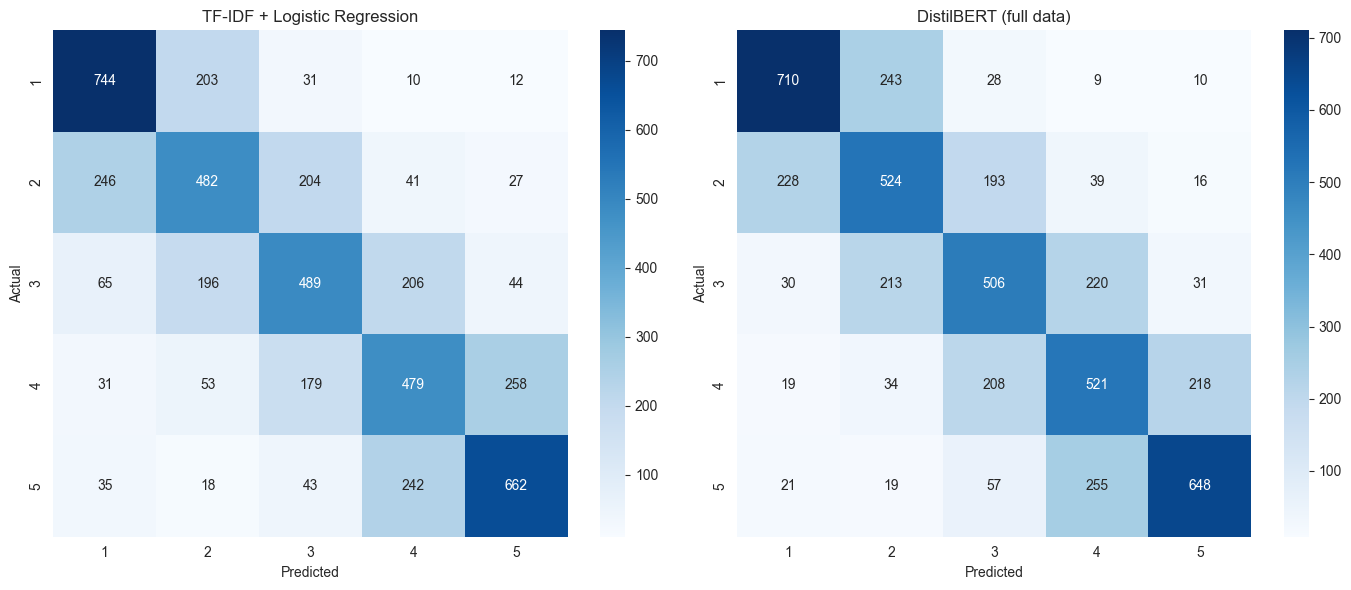

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, name in [(axes[0], tfidf_test_pred, 'TF-IDF + Logistic Regression'),
                       (axes[1], bert_test_pred, 'DistilBERT (full data)')]:
    cm = confusion_matrix(test_df['stars'], pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax,
    xticklabels=range(1,6), yticklabels=range(1,6))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 6. Error analysis - what does the final model actually get wrong?
Looking at specific misclassified reviews, not just the aggregate numbers, to understand *why* errors happen - this turns the confusion matrix into a real, specific finding worth discussing.

In [14]:
test_df['bert_pred'] = bert_test_pred
test_df['bert_correct'] = test_df['bert_pred'] == test_df['stars']

#focusing on the hardest, most common error type: adjacent-class confusion
#on the middle ratings (3-4 stars), which every approach struggled with
adjacent_errors = test_df[
    (~test_df['bert_correct']) &
    (test_df['stars'].isin([3,4])) &
    ((test_df['bert_pred'] - test_df['stars']).abs() == 1)
]

print(f"Adjacent 3-4 star errors: {len(adjacent_errors)}")
print()
for _, row in adjacent_errors.sample(5, random_state=42).iterrows():
    print(f"Actual: {row['stars']} | Predicted: {row['bert_pred']}")
    print(row['text'][:300])
    print('---')

Adjacent 3-4 star errors: 859

Actual: 4 | Predicted: 3
Got to say, busy Starbucks! \n\nI tend to stop in here when I head to Costco.  Every time I come, always a long line.  Service is friendly and pleasing.  I noticed only a few tables available, but usually occupied by patrons.  Space is very tight; hardly any room to walk.  My drinks come out very we
---
Actual: 4 | Predicted: 3
Saw this on diners drive in and dives and the very next day I was standing in line in 100 degree heat to try some BBQ. \n\nBe prepared to sweat a bit even though they offer free lemonade while you wait! The \"restaurant\" is more like an outdoor BBQ. You order and pay and they pull your order from t
---
Actual: 3 | Predicted: 4
First off, I don't eat donuts.\n\nThat said as a child I loved them.  Now I have children and they love them.  It is so fun for them to stand in front of the case and look at all the donuts before picking the one they want to buy and eat.\n\nThis location was very clean and the gentl

With the adjacent errors, the pattern I see is mixed sentiment; people may enjoyed some aspect of the service or food but the praise is mild and may have been difficult for the models to distinguish between geniune enthusiasm and things reviewers wished were better.

/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_35614/2623532049.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Incorrect', 'Correct'])


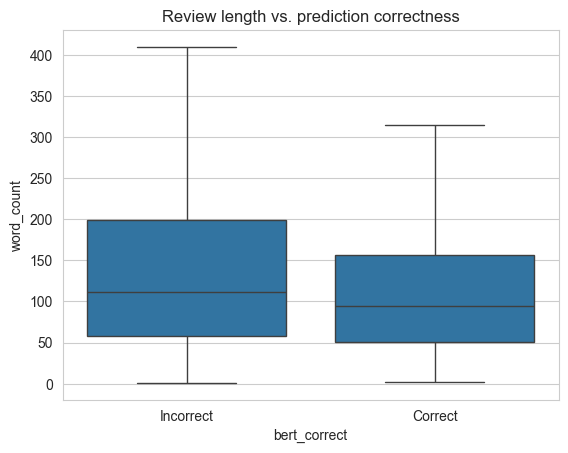

In [15]:
#does review length relate to error rate?
test_df['word_count'] = test_df['text'].str.split().str.len()

fig, ax = plt.subplots()
sns.boxplot(x='bert_correct', y='word_count', data=test_df, ax=ax, showfliers=False)
ax.set_xticklabels(['Incorrect', 'Correct'])
ax.set_title('Review length vs. prediction correctness')
plt.show()

In [17]:
test_df.groupby('bert_correct')['word_count'].median().reset_index()

,bert_correct,word_count
0,False,112.0
1,True,94.0


The average word count of the incorrect predictions are much longer than the reviews that were predicted correctly. It's likely the `max_length = 128` parameter used in the model to truncate reviews affected the model's ability to predict the rating for reviews that were longer.

## 7. Final model choice: accuracy vs. deployment cost

| Consideration | TF-IDF + Logistic Regression | DistilBERT (full data) |
| --- | --- | --- |
| Test Macro F1 | 0.5687 | 0.5829 |
| Model size | ~1-5 MB | ~250+MB | 
| Deployment dependencies | scikit-learn only | torch + transformers |
| Inference speed | Very fast (milliseconds, CPU) | Slower (still usable, but heavier per-request) |
| Interpretability | Coefficients somewhat inspectable | Effectively a black box without extra tooling (e.g. attention visualization) |

Between the final two models, the BERT model is more accurate and better at predicting 1-star, 2-star, 4-star, and 5-star reviews; however its much larger than the TF-IDF model and much slower. The TF-IDF model is not too far off in terms of accuracy, it's simplier, faster and has less infrastructure costs. </br>
However for the final model, I recommend going with the TF-IDF model because the accuracy gain from the BERT model is not worth the high deployment costs.

## 8. Summary
The final test-set numbers for each model: 0.5687 for the TF-IDF + Logistic Regression and 0.5829 for the DistilBERT model; both models were close to the validation set numbers which means they both generalized the data well. The BERT model struggled when the reviews were good but there were things a reviewer thought could be better (struggled with nuance between an okay review and a glowing review). In the end, I chose the TF-IDF model because it simplier, less expensive and faster to deploy. </br>
Next: Build the API around the chosen final model, update `src/predict.py` and `requirements-app.txt` to match the final model, and deploy.